In [167]:
import qiskit as qk
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [168]:
# work by Copyright (C) 205 Joachim Kopp (jkopp@cern.ch), Malte Buschmann (m.s.a.buschmann@uva.nl)

# Optimized u_{ij} operator
# -------------------------
# This introduces no global phase:
# u_ij(theta) = exp(-i theta/2 * (XX + YY + ZZ))
def u_ij(qc, p, q, theta, nonlocal_gate='ecr', connections=None, qubit_map=None):
    """
    Add the optimized u_{ij} = exp(-i theta/2 * (XX + YY + ZZ))
    operator to a quantum circuit.
    
    Parameters:
        qc:    the circuit
        p, q:  the qubits concerned
        theta: the rotation angle
        nonlocal_gate: which non-local gate to use ('ecr' or 'cx')
        connections:   A list of qubit pairs that are connected to one another,
                       including the direction. Will be used for checking that the
                       desired u_{ij} operation is possible on this hardware
                       and reorders qubits to ensure proper directionality
        qubit_map:     The map from logical to physical qubits. If not None,
                       connections is interpreted as a list of physical connections,
                       while p, q are interpreted as logical qubit indices.
    """
    
    if nonlocal_gate.upper() == 'ECR':
        # Reassign p, q to match ECR gate orientation 
        if connections is not None:
            if qubit_map is None:
                if (p, q) not in connections:
                    if (q, p) in connections:
                        p, q = q, p
                    else:
                        raise ValueError(f'Qubits {p} and {q} are not connected on the device.')
            else:
                if (qubit_map[p], qubit_map[q]) not in connections:
                    if (qubit_map[q], qubit_map[p]) in connections:
                        p, q = q, p
                    else:
                        raise ValueError(f'Qubits {qubit_map[p]} and {qubit_map[q]} are not connected on the device.')
        
        qc.rz(-np.pi/2, p)
        qc.sx(p)

        qc.rz(np.pi/2, q)
        qc.sx(q)
        qc.rz(-np.pi, q)
        #---------------------
        qc.ecr(p, q)
        #---------------------
        qc.sx(p)
        qc.rz(-theta, p)
        qc.sx(p)
        qc.rz(-np.pi/2, p)

        qc.sx(q)
        qc.rz(theta, q)
        qc.sx(q)
        qc.rz(-np.pi/2, q)
        #---------------------
        qc.ecr(p, q)
        #---------------------
        qc.sx(p)
        qc.rz(-theta, p)
        qc.sx(p)

        qc.rz(-np.pi/2, q)
        #---------------------
        qc.ecr(p, q)
        #---------------------
        qc.rz(-np.pi/2, p)
        qc.sx(p)
        qc.rz(np.pi/2, p)

        qc.rz(np.pi/2, q)
        qc.sx(q)
        qc.rz(-np.pi/2, q)
        
    elif nonlocal_gate.upper() == 'CX':
        raise ValueError('representation of u_{ij} in terms of CX not implemented yet.')
        
    else:
        raise ValueError(f'invalid basis gate: {nonlocal_gate}')


In [169]:
# check that changing theta -> theta-np.pi/2 implements an extra SWAP
theta = 0.1
qc = qk.QuantumCircuit(2)
u_ij(qc, 0, 1, theta)
# qc.rxx(theta, 0, 1)
# qc.ryy(theta, 0, 1)
# qc.rzz(theta, 0, 1)
#display(qc.draw())
op1 = np.array(qk.quantum_info.Operator(qc))
op1.real[abs(op1.real)<1e-13]=0
op1.imag[abs(op1.imag)<1e-13]=0

theta = 0.1
qc = qk.QuantumCircuit(2)
u_ij(qc, 0, 1, theta)
qc.swap(0, 1)
# qc.rxx(theta, 0, 1)
# qc.ryy(theta, 0, 1)
# qc.rzz(theta, 0, 1)
#display(qc.draw())
opswap = np.array(qk.quantum_info.Operator(qc))
opswap.real[abs(op1.real)<1e-13]=0
opswap.imag[abs(op1.imag)<1e-13]=0

qc = qk.QuantumCircuit(2)
u_ij(qc, 0, 1, theta-np.pi/2)
# qc.rxx(theta-np.pi/2, 0, 1)
# qc.ryy(theta-np.pi/2, 0, 1)
# qc.rzz(theta-np.pi/2, 0, 1)
#display(qc.draw())
op2 = np.array(qk.quantum_info.Operator(qc))
op2.real[abs(op2.real)<1e-13]=0
op2.imag[abs(op2.imag)<1e-13]=0

np.set_printoptions(precision=3)
print(op1)
print((np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]]) @ op1) * np.exp(1j*np.pi/4))
print(op2)
print(opswap)
np.set_printoptions(precision=8)

[[0.999-0.05j 0.   +0.j   0.   +0.j   0.   +0.j  ]
 [0.   +0.j   0.994+0.05j 0.005-0.1j  0.   +0.j  ]
 [0.   +0.j   0.005-0.1j  0.994+0.05j 0.   +0.j  ]
 [0.   +0.j   0.   +0.j   0.   +0.j   0.999-0.05j]]
[[0.742+0.671j 0.   +0.j    0.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.074-0.067j 0.668+0.738j 0.   +0.j   ]
 [0.   +0.j    0.668+0.738j 0.074-0.067j 0.   +0.j   ]
 [0.   +0.j    0.   +0.j    0.   +0.j    0.742+0.671j]]
[[0.742+0.671j 0.   +0.j    0.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.074-0.067j 0.668+0.738j 0.   +0.j   ]
 [0.   +0.j    0.668+0.738j 0.074-0.067j 0.   +0.j   ]
 [0.   +0.j    0.   +0.j    0.   +0.j    0.742+0.671j]]
[[0.999-0.05j 0.   +0.j   0.   +0.j   0.   +0.j  ]
 [0.   +0.j   0.005-0.1j  0.994+0.05j 0.   +0.j  ]
 [0.   +0.j   0.994+0.05j 0.005-0.1j  0.   +0.j  ]
 [0.   +0.j   0.   +0.j   0.   +0.j   0.999-0.05j]]


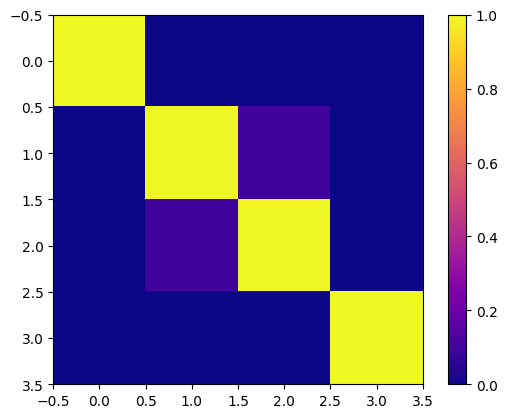

Optimization successful
1.3759167875699555e-15


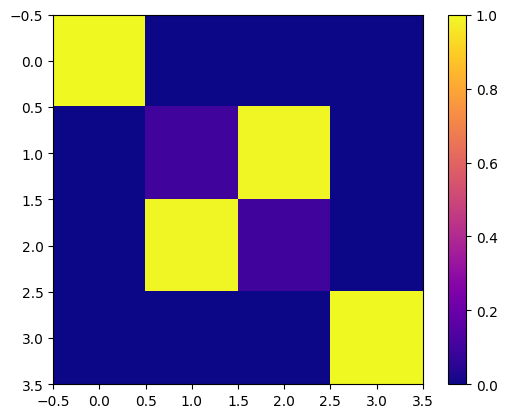

[[0.999-0.05j 0.   +0.j   0.   +0.j   0.   +0.j  ]
 [0.   +0.j   0.994+0.05j 0.005-0.1j  0.   +0.j  ]
 [0.   +0.j   0.005-0.1j  0.994+0.05j 0.   +0.j  ]
 [0.   +0.j   0.   +0.j   0.   +0.j   0.999-0.05j]]
[[0.999-0.05j 0.   +0.j   0.   +0.j   0.   +0.j  ]
 [0.   +0.j   0.005-0.1j  0.994+0.05j 0.   +0.j  ]
 [0.   +0.j   0.994+0.05j 0.005-0.1j  0.   +0.j  ]
 [0.   +0.j   0.   +0.j   0.   +0.j   0.999-0.05j]]
[[0.999-0.05j 0.   +0.j   0.   +0.j   0.   +0.j  ]
 [0.   +0.j   0.005-0.1j  0.994+0.05j 0.   +0.j  ]
 [0.   +0.j   0.994+0.05j 0.005-0.1j  0.   +0.j  ]
 [0.   +0.j   0.   +0.j   0.   +0.j   0.999-0.05j]]
x: [-0.5         0.24999999]


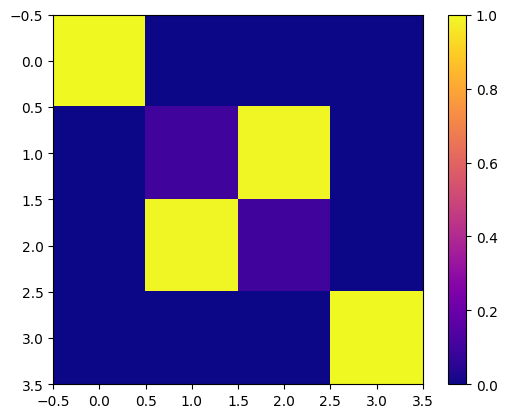

In [170]:
# check that changing theta -> theta-np.pi/2 implements an extra SWAP
theta = 0.1
qc = qk.QuantumCircuit(2)
u_ij(qc, 0, 1, theta)
# qc.rxx(theta, 0, 1)
# qc.ryy(theta, 0, 1)
# qc.rzz(theta, 0, 1)
#display(qc.draw())
op1 = np.array(qk.quantum_info.Operator(qc))
op1.real[abs(op1.real)<1e-13]=0
op1.imag[abs(op1.imag)<1e-13]=0
plt.imshow(np.abs(op1), cmap='plasma')
plt.colorbar()
plt.show()

def objective(x):
    qc = qk.QuantumCircuit(2)
    u_ij(qc, 0, 1, theta-x[0])
    o = np.array(qk.quantum_info.Operator(qc)) * np.exp(1j*x[1])
    return np.sum(np.abs(o - (np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]]) @ op1))**2)

x0 = np.array([-np.pi/2, 0])

res = sp.optimize.minimize(objective, x0, method='BFGS', tol=1e-6)

if res.success:
    print('Optimization successful')
    print(objective(res.x))
else:
    print('Optimization failed')

x = res.x

qc = qk.QuantumCircuit(2)
u_ij(qc, 0, 1, theta-x[0])
# qc.rxx(theta-np.pi/2, 0, 1)
# qc.ryy(theta-np.pi/2, 0, 1)
# qc.rzz(theta-np.pi/2, 0, 1)
#display(qc.draw())
op2 = np.array(qk.quantum_info.Operator(qc)) * np.exp(1j*x[1])
op2.real[abs(op2.real)<1e-13]=0
op2.imag[abs(op2.imag)<1e-13]=0
plt.imshow(np.abs(op2), cmap='plasma')
plt.colorbar()
plt.show()

np.set_printoptions(precision=3)
print(op1)
print((np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]]) @ op1))
plt.imshow(np.abs((np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]]) @ op1)), cmap='plasma')
plt.colorbar()
print(op2)
np.set_printoptions(precision=8)

print('x:', x / np.pi)

In [171]:
# solving for three flavour angles

In [172]:
def nunu_interaction(qc, q, alpha):
    a, b, c, d = q
    qc.cx(a, c)
    qc.cx(b, d)
    qc.ry(np.pi/4, a)
    qc.ry(np.pi/4, b)
    qc.cx(c, a)
    qc.cx(d, b)
    qc.ry(-np.pi/4, a)
    qc.ry(-np.pi/4, b)
    qc.rz(-alpha, c)
    qc.rz(-alpha, d)
    qc.cx(a, c)
    qc.cx(b, d)
    qc.cx(a, b)
    qc.rz(-2 * alpha, b)
    qc.rz(alpha, c)
    qc.rz(alpha, d)
    qc.cx(a, b)
    qc.cx(b, c)
    qc.rz(alpha, c)
    qc.cx(a, c)
    qc.rz(-alpha, c)
    qc.cx(a, d)
    qc.cx(b, c)
    qc.rz(alpha, d)
    qc.cx(b, d)
    qc.rz(-alpha, d)
    qc.cx(a, d)
    qc.ry(np.pi/4, a)
    qc.ry(np.pi/4, b)
    qc.cx(d, b)
    qc.cx(c, a)
    qc.ry(-np.pi/4, a)
    qc.ry(-np.pi/4, b)
    qc.cx(b, d)
    qc.cx(a, c)

In [173]:
def nunu_interaction_p(qc, q, alpha, p):
    a, b, c, d = q
    qc.cx(a, c)
    qc.cx(b, d)
    qc.ry(np.pi/4, a)
    qc.ry(np.pi/4, b)
    qc.cx(c, a)
    qc.cx(d, b)
    qc.ry(-np.pi/4, a)
    qc.ry(-np.pi/4, b)
    qc.rz(-alpha, c)
    qc.rz(-alpha + p[0], d)
    qc.cx(a, c)
    qc.cx(b, d)
    qc.cx(a, b)
    qc.rz(-2 * alpha + p[0], b)
    qc.rz(alpha, c)
    qc.rz(alpha + p[1], d)
    qc.cx(a, b)
    qc.cx(b, c)
    qc.rz(alpha + p[1], c)
    qc.cx(a, c)
    qc.rz(-alpha + p[0], c)
    qc.cx(a, d)
    qc.cx(b, c)
    qc.rz(alpha, d)
    qc.cx(b, d)
    qc.rz(-alpha, d)
    qc.cx(a, d)
    qc.ry(np.pi/4, a)
    qc.ry(np.pi/4, b)
    qc.cx(d, b)
    qc.cx(c, a)
    qc.ry(-np.pi/4, a)
    qc.ry(-np.pi/4, b)
    qc.cx(b, d)
    qc.cx(a, c)

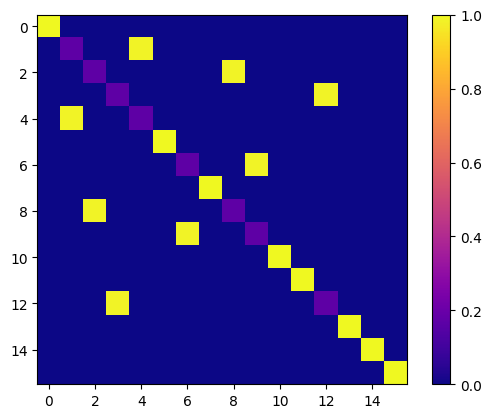

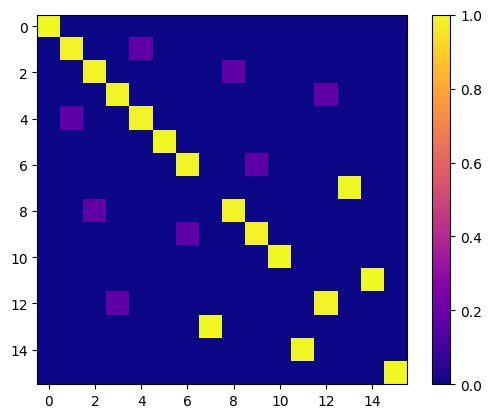

Optimization successful
2.4390499998896428e-15


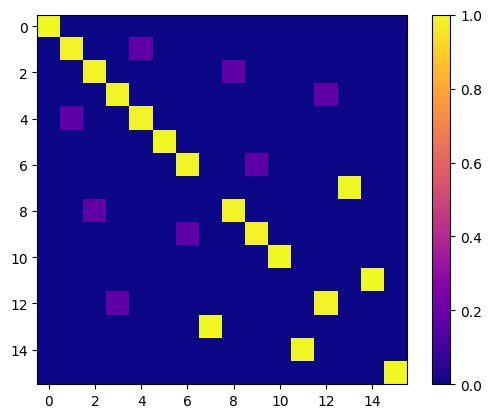

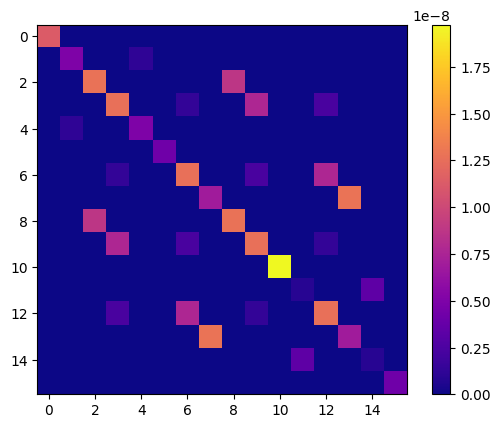

[[0.765+0.644j 0.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j
  0.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j
  0.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j
  0.   +0.j   ]
 [0.   +0.j    0.13 -0.109j 0.   +0.j    0.   +0.j    0.635+0.754j
  0.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j
  0.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j
  0.   +0.j   ]
 [0.   +0.j    0.   +0.j    0.13 -0.109j 0.   +0.j    0.   +0.j
  0.   +0.j    0.   +0.j    0.   +0.j    0.635+0.754j 0.   +0.j
  0.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j
  0.   +0.j   ]
 [0.   +0.j    0.   +0.j    0.   +0.j    0.13 -0.109j 0.   +0.j
  0.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j
  0.   +0.j    0.   +0.j    0.635+0.754j 0.   +0.j    0.   +0.j
  0.   +0.j   ]
 [0.   +0.j    0.635+0.754j 0.   +0.j    0.   +0.j    0.13 -0.109j
  0.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j
  0.   +0.j    0.   +0.j    0.   +

In [174]:
# check that changing theta -> theta-np.pi/2 implements an extra SWAP
theta = 0.7
qc = qk.QuantumCircuit(4)
nunu_interaction(qc, [0, 1, 2, 3], theta)
# qc.rxx(theta, 0, 1)
# qc.ryy(theta, 0, 1)
# qc.rzz(theta, 0, 1)
#display(qc.draw())
op1 = np.array(qk.quantum_info.Operator(qc))
op1.real[abs(op1.real)<1e-13]=0
op1.imag[abs(op1.imag)<1e-13]=0
plt.imshow(np.abs(op1), cmap='plasma')
plt.colorbar()
plt.show()

qc = qk.QuantumCircuit(4)
nunu_interaction(qc, [0, 1, 2, 3], theta)
qc.swap(0, 2)
qc.swap(1, 3)
# qc.rxx(theta, 0, 1)
# qc.ryy(theta, 0, 1)
# qc.rzz(theta, 0, 1)
#display(qc.draw())
oswap = np.array(qk.quantum_info.Operator(qc))
oswap.real[abs(oswap.real)<1e-13]=0
oswap.imag[abs(oswap.imag)<1e-13]=0
plt.imshow(np.abs(oswap), cmap='plasma')
plt.colorbar()
plt.show()

def objective(x):
    qc = qk.QuantumCircuit(4)
    nunu_interaction_p(qc, [0, 1, 2, 3], theta, x[0:-1])
    o = np.array(qk.quantum_info.Operator(qc)) * np.exp(1j*x[-1])
    return np.sum(np.abs(o - oswap)**2)

x0 = np.zeros(3) + 0.1
 
res = sp.optimize.minimize(objective, x0, method='BFGS', tol=1e-6)

if res.success:
    print('Optimization successful')
    print(objective(res.x))
else:
    print('Optimization failed')

x = res.x

qc = qk.QuantumCircuit(4)
nunu_interaction_p(qc, [0, 1, 2, 3], theta, x[0:-1])
# qc.rxx(theta-np.pi/2, 0, 1)
# qc.ryy(theta-np.pi/2, 0, 1)
# qc.rzz(theta-np.pi/2, 0, 1)
#display(qc.draw())
op2 = np.array(qk.quantum_info.Operator(qc)) * np.exp(1j*x[-1])
op2.real[abs(op2.real)<1e-13]=0
op2.imag[abs(op2.imag)<1e-13]=0
plt.imshow(np.abs(op2), cmap='plasma')
plt.colorbar()
plt.show()

plt.imshow(np.abs(op2 - oswap), cmap='plasma')
plt.colorbar()
plt.show()

np.set_printoptions(precision=3)
print(op1)
print(oswap)
print(op2)
np.set_printoptions(precision=20)

print('x:', x / np.pi)

In [175]:
for theta in np.linspace(0, 2*np.pi, 1000):
    # check that the rotation implements an extra SWAP
    qc = qk.QuantumCircuit(4)
    nunu_interaction(qc, [0, 1, 2, 3], theta)
    qc.swap(0, 2)
    qc.swap(1, 3)
    # qc.rxx(theta, 0, 1)
    # qc.ryy(theta, 0, 1)
    # qc.rzz(theta, 0, 1)
    #display(qc.draw())
    oswap = np.array(qk.quantum_info.Operator(qc))

    qc = qk.QuantumCircuit(4)
    nunu_interaction_p(qc, [0, 1, 2, 3], theta, x[0:-1])
    # qc.rxx(theta-np.pi/2, 0, 1)
    # qc.ryy(theta-np.pi/2, 0, 1)
    # qc.rzz(theta-np.pi/2, 0, 1)
    #display(qc.draw())
    op2 = np.array(qk.quantum_info.Operator(qc)) * np.exp(1j*x[-1])

    if np.sum(np.abs(op2 - oswap)**2) > 1e-6:
        print('not equal')
        print(theta)
        print(np.sum(np.abs(op2 - oswap)**2))
        print(op2)
        print(oswap)
        raise ValueError('not equal')
